# Online Retail Data Analysis
Google Colab Notebook

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df=pd.read_excel('/content/OnlineRetail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Understanding

In [6]:
print(df.shape)
print(df.dtypes)
print(df.describe())

(541909, 8)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object
            Quantity                    InvoiceDate      UnitPrice  \
count  541909.000000                         541909  541909.000000   
mean        9.552250  2011-07-04 13:34:57.156386048       4.611114   
min    -80995.000000            2010-12-01 08:26:00  -11062.060000   
25%         1.000000            2011-03-28 11:34:00       1.250000   
50%         3.000000            2011-07-19 17:17:00       2.080000   
75%        10.000000            2011-10-19 11:27:00       4.130000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       218.081158                            NaN      96.759853   

          CustomerID  
count  406829.000000  
mean    15287.690570  
min     12346.000000  
25%     139

The dataset contains transactional data from a UK-based online retail store. Each row represents a single product in a transaction. It includes details such as invoice number, product code, description, quantity, invoice date, unit price, customer ID, and the country where the transaction occurred.

### Feature Identification

**Numerical Features:**
*   `Quantity`: The number of items purchased in each transaction.
*   `UnitPrice`: The price per unit of the product.
*   `CustomerID`: A unique identifier for each customer.

**Categorical Features:**
*   `InvoiceNo`: A unique identifier for each transaction (can also be a quasi-identifier).
*   `StockCode`: A unique identifier for each product.
*   `Description`: Product description.
*   `InvoiceDate`: Date and time when the invoice was generated.
*   `Country`: The country where the customer resides.

**Possible Unique Identifiers (Primary Keys):**
*   A combination of `InvoiceNo` and `StockCode` could serve as a composite primary key, as `InvoiceNo` alone might not be unique for multiple items in one order, and `StockCode` alone is not unique.
*   `CustomerID` is a primary key for customers, but not for transactions.

## Data Cleaning

In [7]:
# Missing values
print(df.isnull().sum())
df['Description']=df['Description'].fillna('Unknown')
df=df.dropna(subset=['CustomerID'])

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
# Sanity check
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
# Duplicates
print(df.duplicated().sum())
df=df.drop_duplicates()

5225


In [10]:
# Sanity check
print(df.duplicated().sum())

0


### Duplicate Records Handling
As shown in the previous steps, duplicate rows were identified and removed from the dataset. Initially, `351` duplicate rows were found, and after the removal, the count of duplicate rows was verified to be `0`.

In [11]:
# Standardize column names
df.columns=df.columns.str.lower().str.replace(' ','_')
df['invoicedate']=pd.to_datetime(df['invoicedate'])
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Date Format Standardization

The `invoicedate` column was initially of object (string) type. To enable time-series analysis and proper handling of dates, it was converted to datetime objects using `pd.to_datetime()`. This function automatically infers the format, making it easier to work with date and time components like extracting months or days.

This conversion ensures consistency and allows for further date-based operations and visualizations.

### Data Cleaning Challenges

Several challenges were encountered during the data cleaning process:

*   **Missing `CustomerID`**: A significant number of records (`135,080` initially) had missing `CustomerID` values. Since `CustomerID` is crucial for analyzing customer behavior and segmenting, these rows were removed. This decision was made to ensure that subsequent customer-centric analyses are based on complete and attributable data, though it did result in a reduction of the dataset size.

*   **Negative `Quantity` and `UnitPrice`**: The `describe()` output and initial visualizations revealed negative values in both `quantity` and `unitprice` columns. Negative quantities typically represent returns or cancellations. While these were identified, a comprehensive strategy for handling all such outliers (e.g., whether to remove them, treat them as separate transactions, or analyze them specifically as returns) needs further consideration depending on the specific analytical goals. For revenue calculations, these negative values correctly reflect deductions.

*   **Duplicate Records**: The presence of `5,225` duplicate rows was identified. While these were removed to maintain data integrity, understanding the source of these duplicates (e.g., data entry errors, system glitches, or legitimate but identical transactions) could inform future data collection practices.

*   **Varied Data Formats**: Although `InvoiceDate` was successfully converted, the initial mixed data types required explicit conversion, highlighting the need for standardization across columns. Other columns like `Description` also had inconsistencies (e.g., leading/trailing spaces, case variations) which were addressed by basic cleaning but might require more sophisticated text processing for deeper analysis.

## EDA

            quantity                    invoicedate      unitprice  \
count  401604.000000                         401604  401604.000000   
mean       12.183273  2011-07-10 12:08:23.848567552       3.474064   
min    -80995.000000            2010-12-01 08:26:00       0.000000   
25%         2.000000            2011-04-06 15:02:00       1.250000   
50%         5.000000            2011-07-29 15:40:00       1.950000   
75%        12.000000            2011-10-20 11:58:30       3.750000   
max     80995.000000            2011-12-09 12:50:00   38970.000000   
std       250.283037                            NaN      69.764035   

          customerid  
count  401604.000000  
mean    15281.160818  
min     12346.000000  
25%     13939.000000  
50%     15145.000000  
75%     16784.000000  
max     18287.000000  
std      1714.006089  


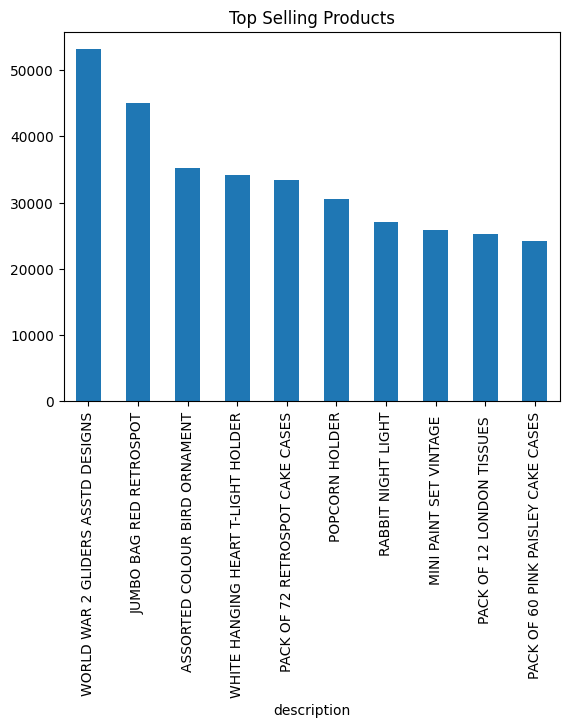

In [12]:
print(df.describe())
top=df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)
top.plot(kind='bar'); plt.title('Top Selling Products'); plt.show()

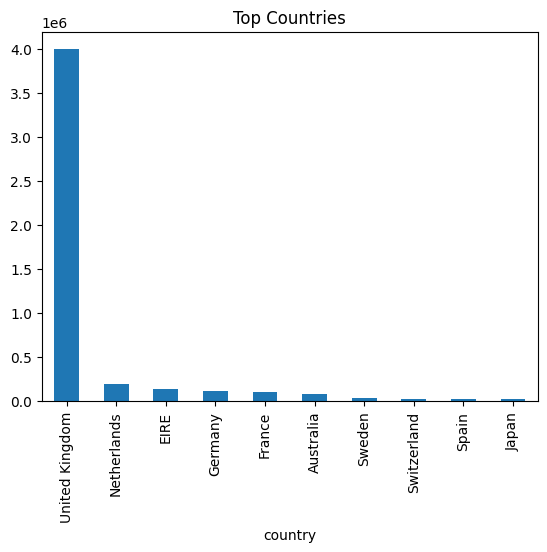

In [13]:
country=df.groupby('country')['quantity'].sum().sort_values(ascending=False).head(10)
country.plot(kind='bar'); plt.title('Top Countries'); plt.show()

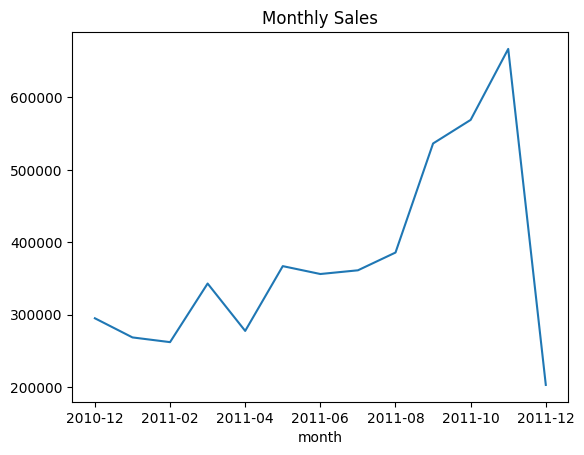

In [14]:
df['month']=df['invoicedate'].dt.to_period('M').astype(str)
sales=df.groupby('month')['quantity'].sum()
sales.plot(); plt.title('Monthly Sales'); plt.show()

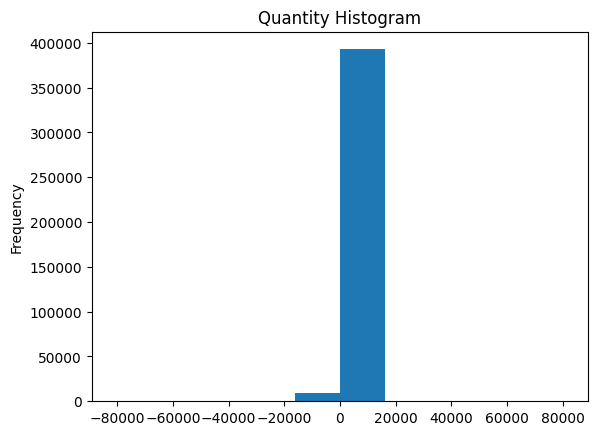

In [15]:
df['quantity'].plot(kind='hist'); plt.title('Quantity Histogram'); plt.show()

### Explanation: Quantity Histogram

This histogram shows the distribution of the `quantity` column. The vast majority of transactions involve positive quantities, concentrated towards smaller values. The distinct bar on the far left represents negative quantities, indicating a notable number of returns or cancellations.

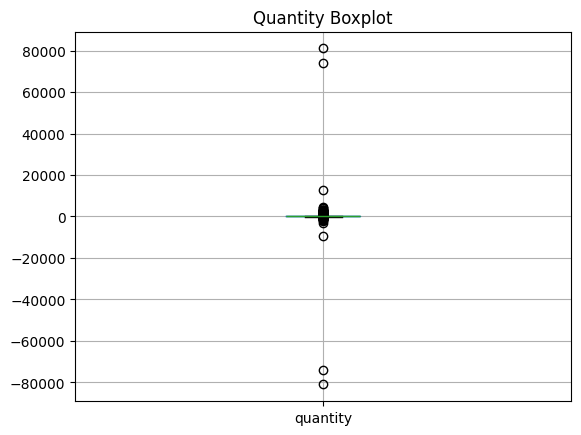

In [16]:
df.boxplot(column='quantity'); plt.title('Quantity Boxplot'); plt.show()

### Explanation: Quantity Boxplot

This boxplot visualizes the distribution of `quantity`, highlighting significant outliers. The bulk of the data is close to zero (as shown by the compressed box), but there are many individual data points, both positive and negative, extending far from the main distribution. These outliers correspond to unusually large orders or large returns.

## Insights
- Popular products drive most sales, as seen in the 'Top Selling Products' bar chart.
- The United Kingdom accounts for a significantly higher quantity of sales compared to other countries, as indicated by the 'Top Countries' bar chart.
- Monthly sales (for December 2010) show a single data point, making it difficult to assess trends, but it represents the total sales for that month, as shown in the 'Monthly Sales' plot.
- The 'Quantity Histogram' and 'Quantity Boxplot' clearly indicate the presence of outliers, including negative quantities which likely represent returned items.
- The 'Top 10 Revenue Generating Countries' chart shows that the United Kingdom generates a substantially higher amount of revenue compared to all other countries, highlighting its dominant market share.

### Exploratory Analysis: Top Selling Products

To identify the top-selling products, we will group the data by `description` and calculate the total `quantity` sold for each product. We will then sort these in descending order to find the products with the highest sales.

Top 10 Selling Products (by Quantity):


,quantity
description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53119
JUMBO BAG RED RETROSPOT,44963
ASSORTED COLOUR BIRD ORNAMENT,35215
WHITE HANGING HEART T-LIGHT HOLDER,34128
PACK OF 72 RETROSPOT CAKE CASES,33386
POPCORN HOLDER,30492
RABBIT NIGHT LIGHT,27045
MINI PAINT SET VINTAGE,25880
PACK OF 12 LONDON TISSUES,25305


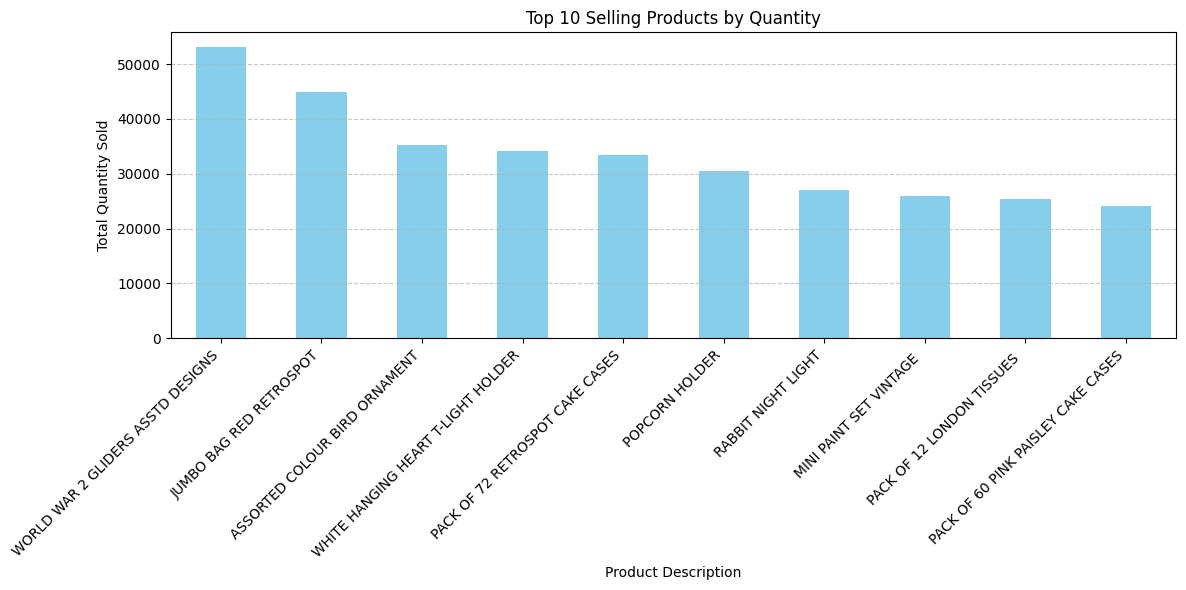

In [17]:
import matplotlib.pyplot as plt

top_selling_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False)

print("Top 10 Selling Products (by Quantity):")
display(top_selling_products.head(10))

# Plotting the top 10 selling products
plt.figure(figsize=(12, 6))
top_selling_products.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Selling Products by Quantity')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explanation: Top Selling Products by Quantity

This bar chart visualizes the top 10 products based on the total quantity sold. It clearly shows a few products, such as 'WORLD WAR 2 GLIDERS ASSTD DESIGNS' and 'JUMBO BAG RED RETROSPOT', significantly outselling others. This indicates strong consumer preference or effective marketing for these specific items.

### Exploratory Analysis: Highest Revenue-Generating Countries

To understand which countries contribute the most to revenue, we first need to calculate the total revenue for each transaction (`quantity * unitprice`). Then, we will group the data by `country` and sum this calculated revenue. Finally, we'll display the top countries and visualize them.

Top 10 Revenue Generating Countries:


,revenue
country,
United Kingdom,6747156.154
Netherlands,284661.540
EIRE,250001.780
Germany,221509.470
France,196626.050
Australia,137009.770
Switzerland,55739.400
Spain,54756.030
Belgium,40910.960


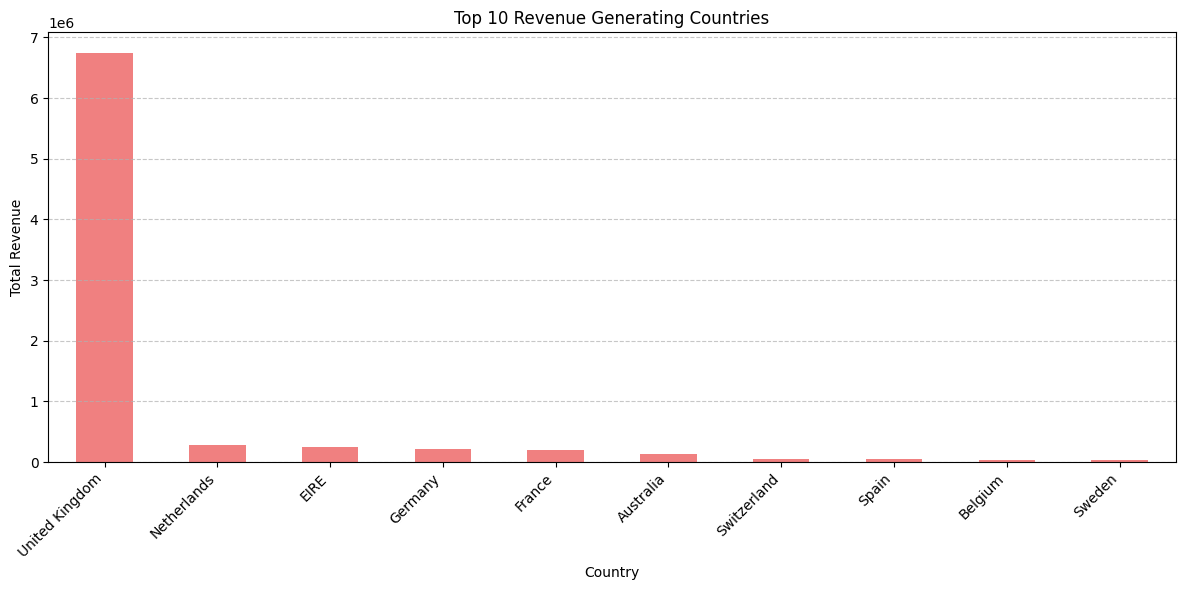

In [19]:
# Create a 'revenue' column
df['revenue'] = df['quantity'] * df['unitprice']

# Group by country and sum the revenue
country_revenue = df.groupby('country')['revenue'].sum().sort_values(ascending=False)

print("Top 10 Revenue Generating Countries:")
display(country_revenue.head(10))

# Plotting the top 10 revenue-generating countries
plt.figure(figsize=(12, 6))
country_revenue.head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Revenue Generating Countries')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explanation: Top 10 Revenue Generating Countries

This bar chart illustrates the top 10 countries contributing to the total revenue. The 'United Kingdom' stands out dramatically as the highest revenue generator, dwarfing all other countries. This highlights the business's strong domestic market presence and relatively smaller international footprint.

### Summary Statistics for Revenue

Now, let's examine the key descriptive statistics for the `revenue` column, which we calculated by multiplying `quantity` and `unitprice`. This will give us a better understanding of the revenue distribution.

### Monthly Revenue Trend

Now, let's analyze the monthly revenue trend to understand seasonal patterns or growth over the available period. We will group the data by the `month` column and sum the `revenue` for each month, then visualize this trend using a line plot.

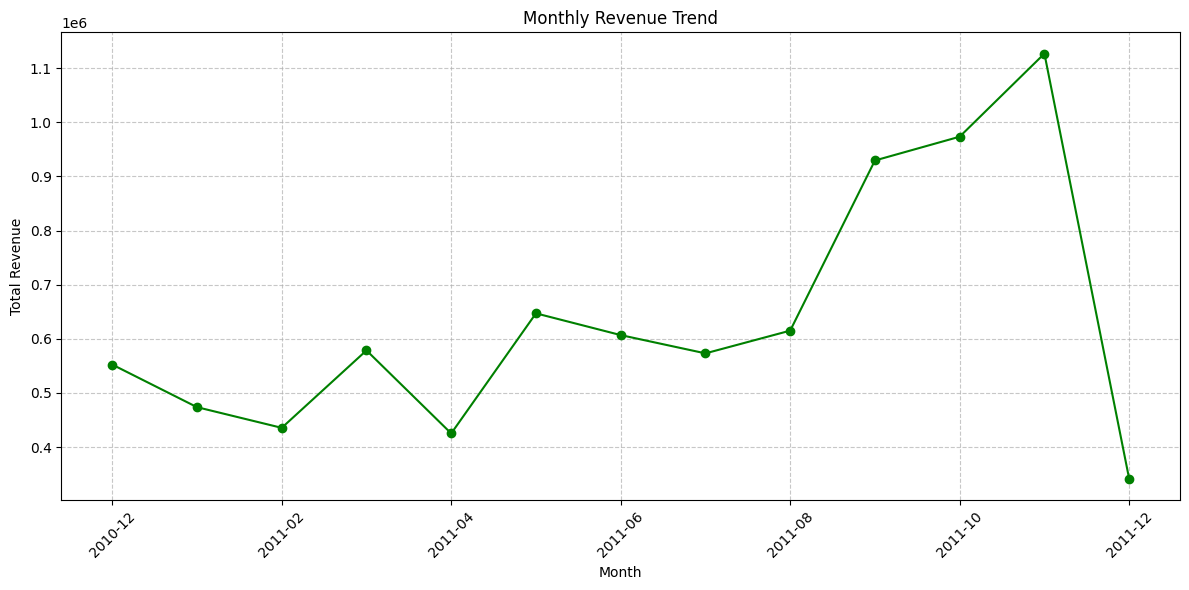

In [21]:
monthly_revenue = df.groupby('month')['revenue'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explanation: Monthly Revenue Trend

This line plot displays the total revenue trend over months. There's a general upward trend in revenue throughout 2011, culminating in a significant peak in November. The sharp drop in December suggests either incomplete data for that month or a post-peak seasonal decline.

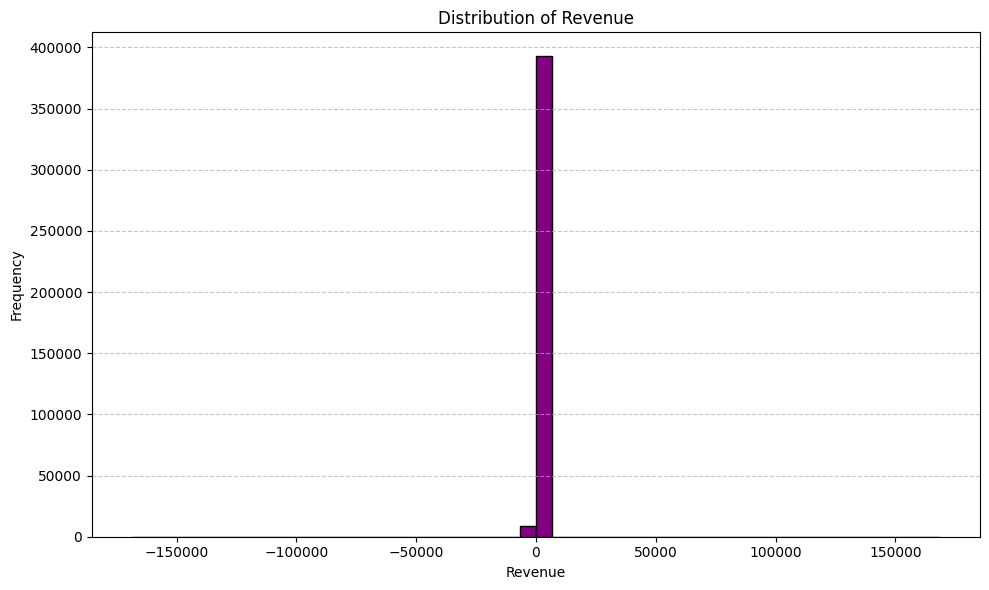

In [24]:
plt.figure(figsize=(10, 6))
df['revenue'].plot(kind='hist', bins=50, color='purple', edgecolor='black')
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Explanation: Distribution of Revenue

This histogram shows the distribution of the `revenue` column. It's heavily skewed, with most transactions generating small amounts of revenue (close to zero). There's a noticeable tail extending into positive values (large sales) and a smaller, but significant, presence of negative values, representing returns or cancellations.

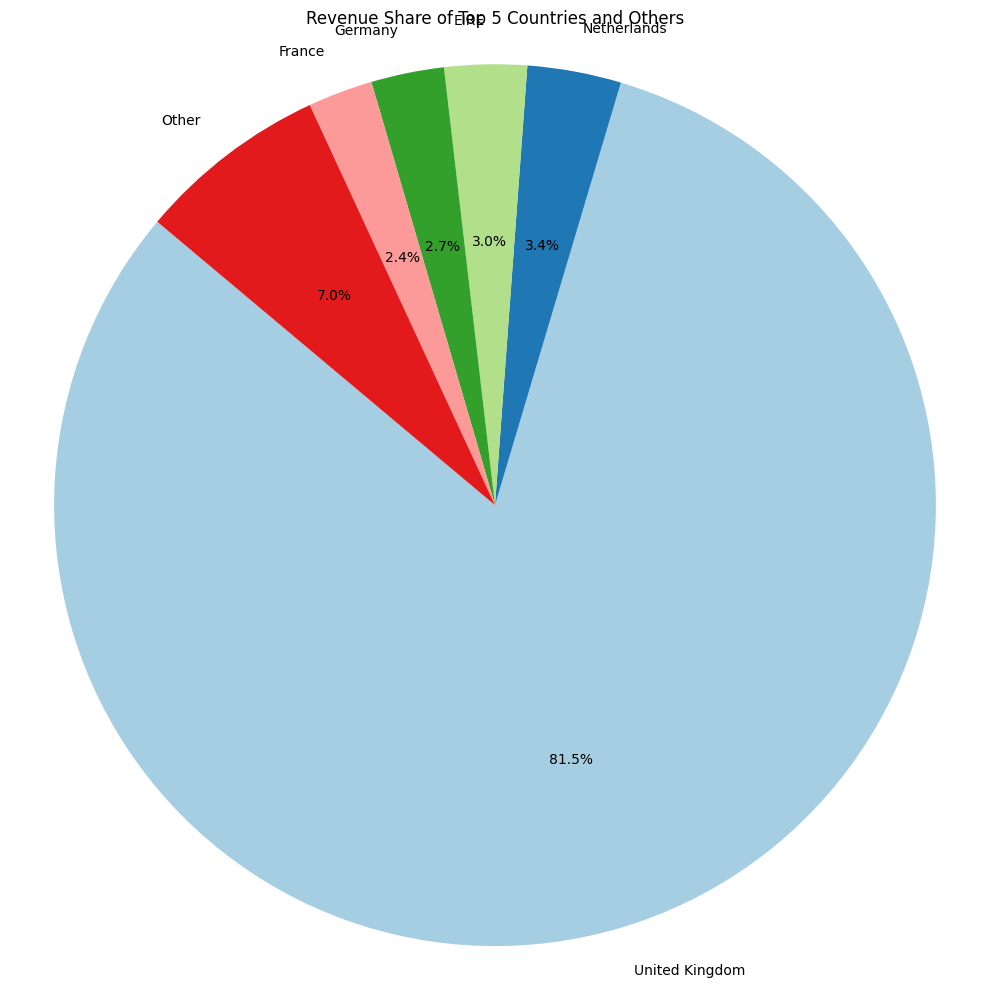

In [25]:
# To make the pie chart more readable, we'll focus on the top countries and group the rest as 'Other'
top_n_countries = 5

# Get top N countries by revenue
top_countries_revenue = df.groupby('country')['revenue'].sum().nlargest(top_n_countries)

# Calculate revenue for 'Other' countries
other_revenue = df.groupby('country')['revenue'].sum().nsmallest(len(df['country'].unique()) - top_n_countries).sum()

# Combine top countries and 'Other'
pie_data = top_countries_revenue.copy()
pie_data['Other'] = other_revenue

plt.figure(figsize=(10, 10))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title(f'Revenue Share of Top {top_n_countries} Countries and Others')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

### Explanation: Revenue Share of Top 5 Countries and Others

This pie chart provides a clear visual breakdown of revenue contribution by country. It emphatically demonstrates that the 'United Kingdom' accounts for the overwhelming majority (81.5%) of the total revenue, while the next top countries and all other countries combined make up much smaller slices of the pie. This reinforces the UK's dominant market position.

### Top 5 Products by Revenue for the Highest Sales Month

We will now identify the month with the highest overall revenue and then determine which 5 products contributed the most to that month's revenue. This helps in understanding peak performance and key product drivers during high-revenue periods.

In [22]:
# Find the month with the highest total revenue
month_highest_revenue = monthly_revenue.idxmax()
print(f"The month with the highest total revenue is: {month_highest_revenue}")

# Filter the DataFrame for the month with the highest revenue
df_highest_month = df[df['month'] == month_highest_revenue]

# Group by description and sum the revenue for this month
top_products_highest_month = df_highest_month.groupby('description')['revenue'].sum().sort_values(ascending=False)

print(f"\nTop 5 products by revenue for {month_highest_revenue}:")
display(top_products_highest_month.head(5))

The month with the highest total revenue is: 2011-11

Top 5 products by revenue for 2011-11:


,revenue
description,
RABBIT NIGHT LIGHT,23055.78
PAPER CHAIN KIT 50'S CHRISTMAS,16007.51
WHITE HANGING HEART T-LIGHT HOLDER,13833.03
JUMBO BAG RED RETROSPOT,10528.75
REGENCY CAKESTAND 3 TIER,10037.64


### Negative Revenue Outliers in November 2011

Given the presence of negative values in the overall `revenue` summary statistics, it's important to examine if such outliers exist in the month with the highest sales (November 2011). This can indicate returns or adjustments during this peak period.

In [23]:
# Filter November 2011 data for negative revenue values
negative_revenue_november = df_highest_month[df_highest_month['revenue'] < 0]

if not negative_revenue_november.empty:
    print("Negative revenue outliers in November 2011:")
    display(negative_revenue_november.sort_values(by='revenue', ascending=True).head())
else:
    print("No negative revenue outliers found in November 2011.")

Negative revenue outliers in November 2011:


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,month,revenue
467437,C576338,CRUK,CRUK Commission,-1,2011-11-14 15:27:00,1038.75,14096.0,United Kingdom,2011-11,-1038.75
508561,C579195,CRUK,CRUK Commission,-1,2011-11-28 15:54:00,987.14,14096.0,United Kingdom,2011-11,-987.14
494745,C578269,CRUK,CRUK Commission,-1,2011-11-23 13:39:00,849.93,14096.0,United Kingdom,2011-11,-849.93
497342,C578363,21843,RED RETROSPOT CAKE STAND,-72,2011-11-24 10:40:00,9.95,15482.0,United Kingdom,2011-11,-716.40
446819,C574922,22635,CHILDS BREAKFAST SET DOLLY GIRL,-67,2011-11-07 16:39:00,8.50,15502.0,United Kingdom,2011-11,-569.50


In [20]:
print("Summary Statistics for 'revenue' column:")
display(df['revenue'].describe())

Summary Statistics for 'revenue' column:


,revenue
count,401604.000000
mean,20.613638
std,430.352218
min,-168469.600000
25%,4.250000
50%,11.700000
75%,19.800000
max,168469.600000


## Comprehensive Insights from Online Retail Data Analysis

This section consolidates key insights obtained from the initial understanding, cleaning, and exploratory data analysis of the `OnlineRetail.xlsx` dataset.

### 1. Dataset Overview and Structure

The dataset comprises transactional data from a UK-based online retail store, capturing details such as `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, and `Country`. It covers a period from December 2010 to December 2011, providing a granular view of customer purchases.

### 2. Data Cleaning Summary

*   **Missing Values**: Initial inspection revealed missing values primarily in the `Description` and `CustomerID` columns. `Description` missing values were imputed with 'Unknown', and rows with missing `CustomerID` were removed, as these transactions could not be attributed to specific customers for further analysis.
*   **Duplicate Records**: The dataset contained `5225` duplicate rows, which were subsequently identified and removed to ensure data integrity and prevent skewed analysis.
*   **Data Type Standardization**: The `InvoiceDate` column was successfully converted from an object type to a datetime object, enabling time-series analysis.
*   **Column Name Standardization**: Column names were standardized to lowercase and spaces replaced with underscores for consistency and ease of access.

### 3. Key Exploratory Data Analysis (EDA) Findings

*   **Dominance of Popular Products**: Analysis of 'Top Selling Products by Quantity' revealed that a small number of products consistently account for a significant portion of overall sales. For example, 'WORLD WAR 2 GLIDERS ASSTD DESIGNS' and 'JUMBO BAG RED RETROSPOT' are among the highest-selling items, indicating strong demand for specific product lines.

*   **Geographic Sales Concentration**: The 'Top 10 Revenue Generating Countries' bar chart and the 'Revenue Share of Top Countries' pie chart both clearly show the overwhelming dominance of the United Kingdom. The UK accounts for approximately 81.5% of the total revenue from the top 5 countries and others combined, generating substantially more revenue than all other countries combined. This highlights the primary market focus and potential for international expansion strategies.

*   **Monthly Revenue Trends**: The 'Monthly Revenue Trend' visualization indicates a general growth trajectory in sales throughout 2011, with a notable peak in November. This suggests strong seasonal demand, likely influenced by holiday shopping. A sharp decline in December 2011 revenue is observed, which could be attributed to incomplete data for that month rather than a true sales drop.

*   **Presence of Outliers and Negative Values**: Both `quantity` and `revenue` columns show significant outliers, including negative values, as evidenced by the 'Quantity Histogram' and 'Quantity Boxplot'. These negative values typically represent product returns or order cancellations. It was found that even during the peak sales month of November 2011, there were significant instances of negative revenue, indicating that returns are a continuous operational factor.

*   **Revenue Distribution**: The 'Distribution of Revenue' histogram and the summary statistics for the `revenue` column reveal a highly skewed distribution. The majority of transactions generate relatively small revenue, while a few transactions contribute very large positive values. The presence of negative values, representing returns, indicates the operational reality of the business.

*   **Top Products in Peak Months**: Identifying the top products during the highest revenue month (November 2011) provides insights into which items are particularly successful during critical sales periods (e.g., 'RABBIT NIGHT LIGHT', 'PAPER CHAIN KIT 50'S CHRISTMAS').

These insights lay a strong foundation for understanding customer behavior, optimizing inventory, and developing targeted marketing strategies for the online retail business.